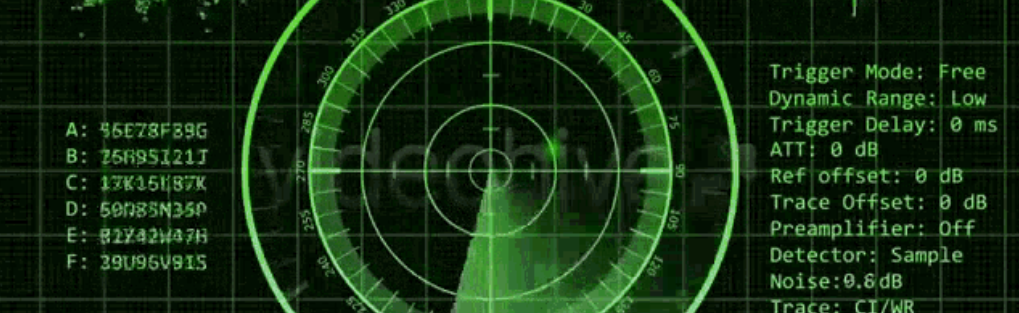

#### This dataset is a clear numerica recrod file of a submerine sonar. We will predict the last feture where M=Mine and R=Rock.We will use logistic regression model to predict this...

### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings #To avoid unusual error we import this
warnings.filterwarnings('ignore')
#we will import scikit learn when we needed......

In [2]:
# Loading the dataset
df=pd.read_csv('sonar data.csv')

In [3]:
df.head()

,1,2,3,4,5,6,7,8,9,10,...,52,53,54,55,56,57,58,59,60,61
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


## Inspecting Basic things at dataset

In [4]:
# size of the dataset
shape=df.shape
#checking for null values
null=df.isnull().sum().sum()
#checking for duplicated values
dup= df.duplicated().sum()

print(f'Shape:{shape}')
print(f'Null values:{null}')
print(f'Duplicate values:{dup}')

#dataset is pretty clear and ready to predict..

Shape:(208, 61)
Null values:0
Duplicate values:0


In [5]:
# checking informaiton of dataset, here all the columns are numeric and last (60) feature is catgorical which we have to predict
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   1       208 non-null    float64
 1   2       208 non-null    float64
 2   3       208 non-null    float64
 3   4       208 non-null    float64
 4   5       208 non-null    float64
 5   6       208 non-null    float64
 6   7       208 non-null    float64
 7   8       208 non-null    float64
 8   9       208 non-null    float64
 9   10      208 non-null    float64
 10  11      208 non-null    float64
 11  12      208 non-null    float64
 12  13      208 non-null    float64
 13  14      208 non-null    float64
 14  15      208 non-null    float64
 15  16      208 non-null    float64
 16  17      208 non-null    float64
 17  18      208 non-null    float64
 18  19      208 non-null    float64
 19  20      208 non-null    float64
 20  21      208 non-null    float64
 21  22      208 non-null    float64
 22  23      208 n

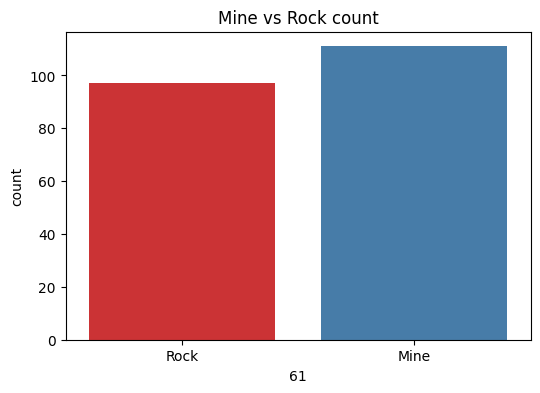

In [6]:
# Replacing R=Rock and M=Mine for better understanding
df['61'] = df['61'].replace({'R': 'Rock', 'M': 'Mine'})

plt.figure(figsize=(6,4))
sns.countplot(x=df['61'], palette='Set1')
plt.title('Mine vs Rock count')
plt.show()

#Here 111-mine and 97-rock is present in our data

#### Our data is preprocessed earlier and it is beautifully scaled. SO now we will start to build prediction mode.

### Spliting teh dataset

In [8]:
X = df.drop(columns='61')
Y = df['61']  # prediction feature

### Training the model

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.1, random_state=42)

from sklearn.linear_model import LogisticRegression  # importing model
model=LogisticRegression()
model.fit(X_train, Y_train) # training the model

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Prediction

In [10]:
Y_pred= model.predict(X_test)

## Evaluation of the Model

In [11]:
from sklearn.metrics import accuracy_score
accuracy= accuracy_score(Y_test,Y_pred)

print(f"The accuracy on test data is: {accuracy*100}%")

# model is looking very good

The accuracy on test data is: 85.71428571428571%


## Building a predictive system

In [16]:
# Generate 60 random numbers with 4 decimal places
# np.random.seed(42)  # Remove this line for truly random each time
random_numbers = np.random.uniform(0.001, 1.000, 60).round(4)

# Print as tuple
value= tuple(random_numbers)

# Print as comma-separated
print('\n', ', '.join(map(str, random_numbers)))


 0.7859, 0.5416, 0.3052, 0.6462, 0.1465, 0.6408, 0.4441, 0.6539, 0.1796, 0.5762, 0.64, 0.3991, 0.337, 0.5478, 0.2307, 0.4693, 0.0908, 0.8775, 0.7153, 0.7228, 0.321, 0.4403, 0.8211, 0.6627, 0.7342, 0.503, 0.3085, 0.8579, 0.9194, 0.8818, 0.1395, 0.1187, 0.1507, 0.6082, 0.1795, 0.0191, 0.3048, 0.9638, 0.4108, 0.0343, 0.1689, 0.4504, 0.6789, 0.189, 0.4027, 0.8455, 0.1259, 0.3752, 0.8649, 0.6827, 0.5508, 0.4968, 0.656, 0.3767, 0.7746, 0.0412, 0.9588, 0.4601, 0.3584, 0.7303


In [17]:
input_data = value
# changing the input_data to a numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the np array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

#Predicting
prediction = model.predict(input_data_reshaped)

# output
print("\n" + "="*30)
print(f"The object is a {prediction[0]}")
print("="*30)


The object is a Mine


### It was a cool projects.....
#### Follow me on github to find more projects: https://github.com/siumahameed
## Thank You